# **Lab 6 Hyperparameter Tuning**

In [1]:
!nvidia-smi
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
# Private user code begin
from torch.utils.tensorboard import SummaryWriter
# Private user code end
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset,Dataset

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import os
import cv2
from skimage.util import random_noise
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

seed = 4912
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

cpuCount = os.cpu_count()
print("Number of CPUs in the system:", cpuCount)

Fri Aug 29 10:30:40 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.01             Driver Version: 535.183.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  | 00000000:47:00.0 Off |                    0 |
| N/A   28C    P0              62W / 400W |   2588MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

2025-08-29 10:30:44.571426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756438244.591930  359961 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756438244.598384  359961 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-29 10:30:46.360002: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Number of CPUs in the system: 256


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))


CUDA available: True
CUDA device count: 1
Current device: 0
Device name: NVIDIA A100-SXM4-40GB


## Data Preparation
Complete the class `CustomImageDataset()` that `__getitem__` return ***noisy blury*** image and ***ground truth*** image.
Please ensure that the final image is in RGBscale and has a size of 128x128.

In [3]:
### START CODE HERE ###
class CustomImageDataset(Dataset):
    def __init__(self, image_paths,gauss_noise=False,center_crop=False,gauss_blur=None,resize=128,p=0.5):
        self.p = p
        self.resize = resize
        self.gauss_noise = gauss_noise
        self.gauss_blur = gauss_blur
        self.center_crop = center_crop
        self.image_paths = image_paths
    
    # ฟังก์ชัน resize รูป
    def apply_resize(self,image):
        resize_img = cv2.resize(image,(self.resize,self.resize))
        return resize_img
    
    # ทำ center crop รูป
    def apply_center_crop(self,image):
        copy_image = np.copy(image)
        tensor_img = torch.from_numpy(copy_image)
        tensor_img = tensor_img.permute(2, 0, 1)
        center_crop_image = transforms.CenterCrop(size=self.resize)(tensor_img)
        # return มาเป็น tensor
        center_crop_image = center_crop_image.permute(1, 2, 0)
        center_crop_image = center_crop_image.detach().numpy()
        # print(center_crop_image.size())
        return center_crop_image

    def apply_gauss_blur(self,image):
        random_kernel = random.choice(range(3, 12, 2)) # kernel ต้องมี size เป็น odd*odd
        blur_image = cv2.GaussianBlur(image,(random_kernel,random_kernel),0)
        return blur_image
    
    def apply_gauss_noise(self,image):
        mean = random.uniform(-50, 50)
        noisy_image = random_noise(image, mode='gaussian', mean= mean/255, var=0.01) #random noise อยากได้รูป range [0,1]
        return (noisy_image * 255).astype(np.uint8)
        
    

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        # read path of image
        gt_image_load = cv2.imread(image_path)[:,:,::-1]
        gt_image = np.copy(gt_image_load)
        
        image = cv2.imread(image_path)[:,:,::-1]
        
        # Crop center 128,128
        if self.center_crop:
            gt_image = self.apply_center_crop(gt_image)
            image = self.apply_center_crop(image)
        else:
            gt_image = self.apply_resize(gt_image)
            image = self.apply_resize(image)
            
        blur_p = random.random()
        if self.gauss_blur and blur_p < self.p:
            image = self.apply_gauss_blur(image) 
            
        gauss_p = random.random()
        if self.gauss_noise and gauss_p < self.p:
            image = self.apply_gauss_noise(image)
        
        
        
        gt_image = torch.from_numpy(gt_image)
        gt_image = gt_image.permute(2, 0, 1)
        

        image = torch.from_numpy(image)
        image = image.permute(2, 0, 1)
        # # print("image size : ",image.size())
        # # print("gt_image size : ",gt_image.size())
        
        return image.float()/255, gt_image.float()/255
### END CODE HERE ###

In [4]:
### START CODE HERE ###
def imshow_grid(images,title=None):
    # images are list of tensor image (CH,H,W)
    num_img = len(images)
    column = 4
    row = (num_img + column - 1) // column
    fig, axes = plt.subplots(row, column, figsize=(15, 15))
    axes = axes.ravel()
    if title:
        fig.suptitle(title)
    for i in range(num_img):
        # print(images[i].min(), images[i].max())
        axes[i].imshow(images[i].permute(1,2,0))
        # print(img.min(), img.max())
        # axes[i].imshow(images[i].astype(np.uint8))
        axes[i].axis('off')  
        
    plt.tight_layout()
    plt.show()

### END CODE HERE ###

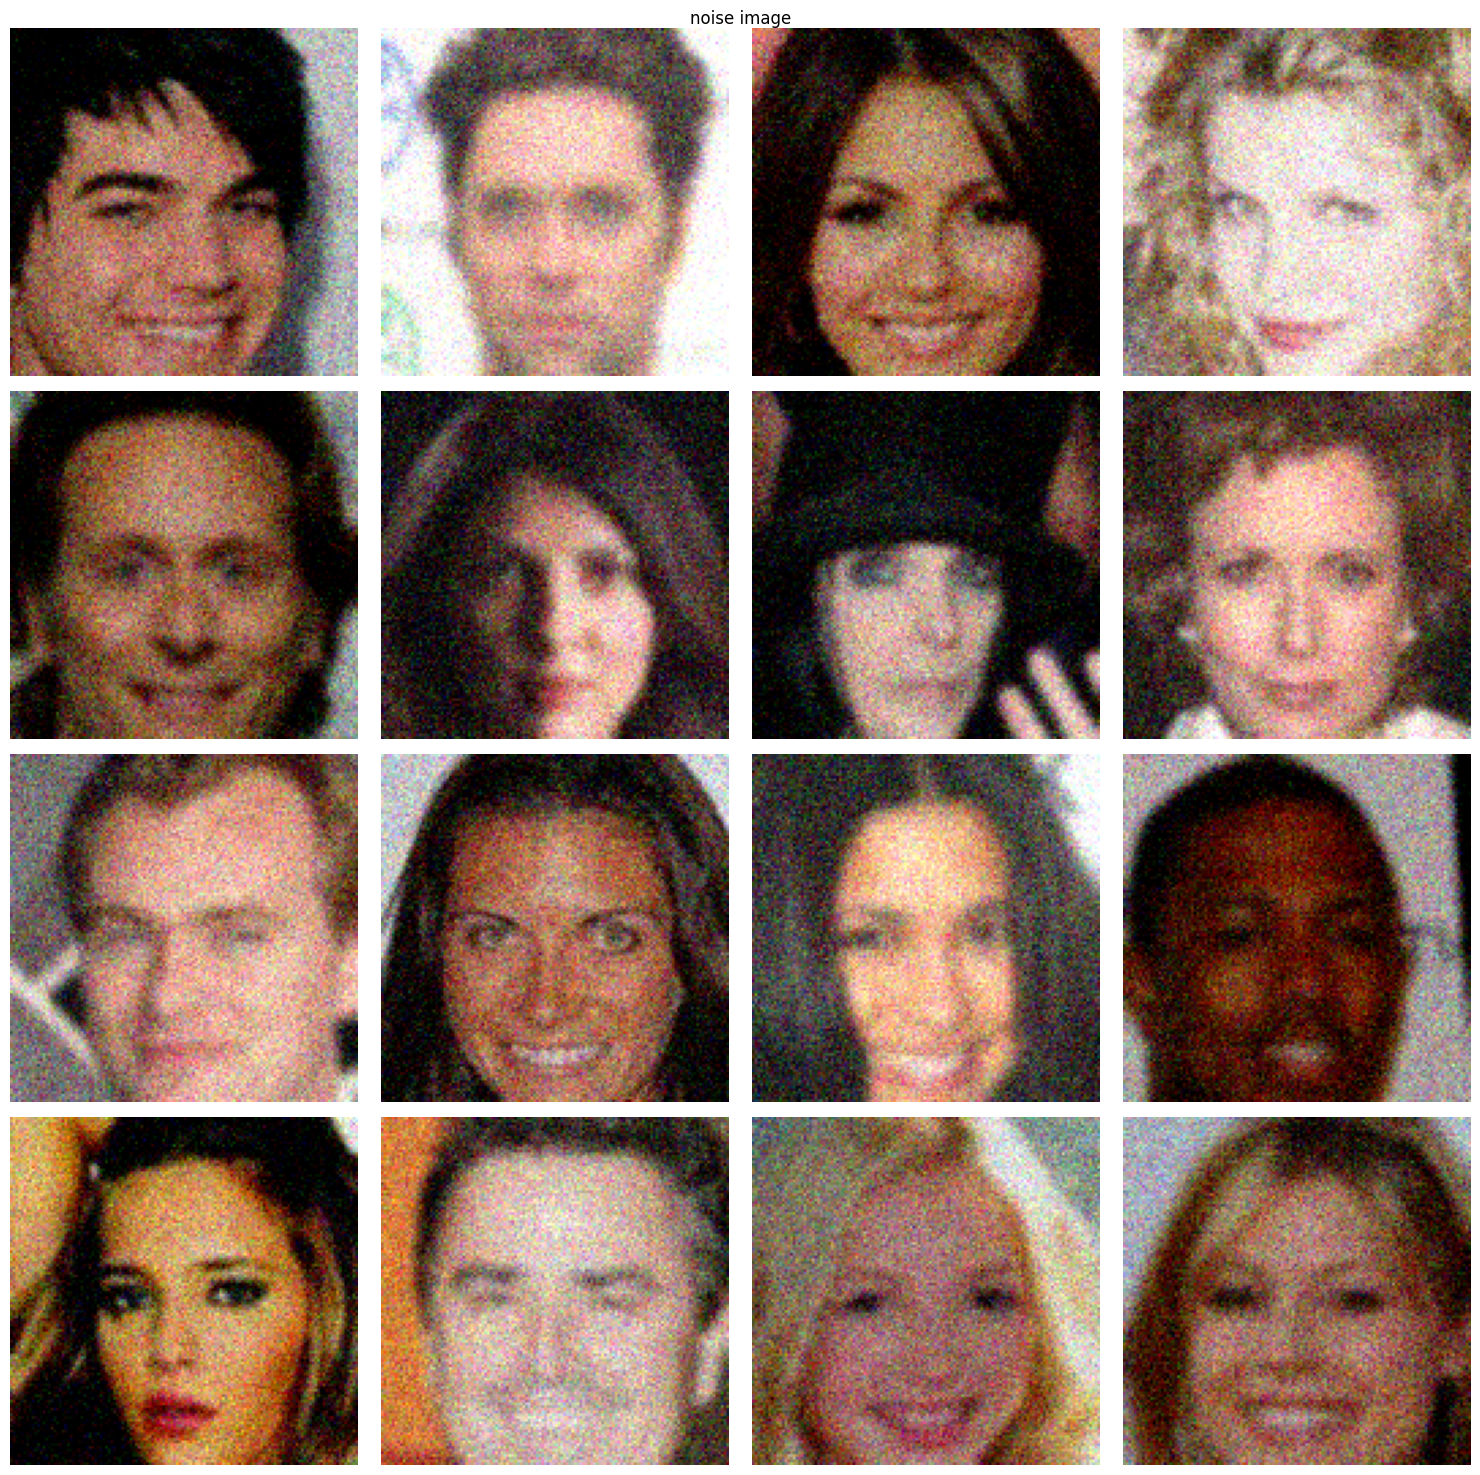

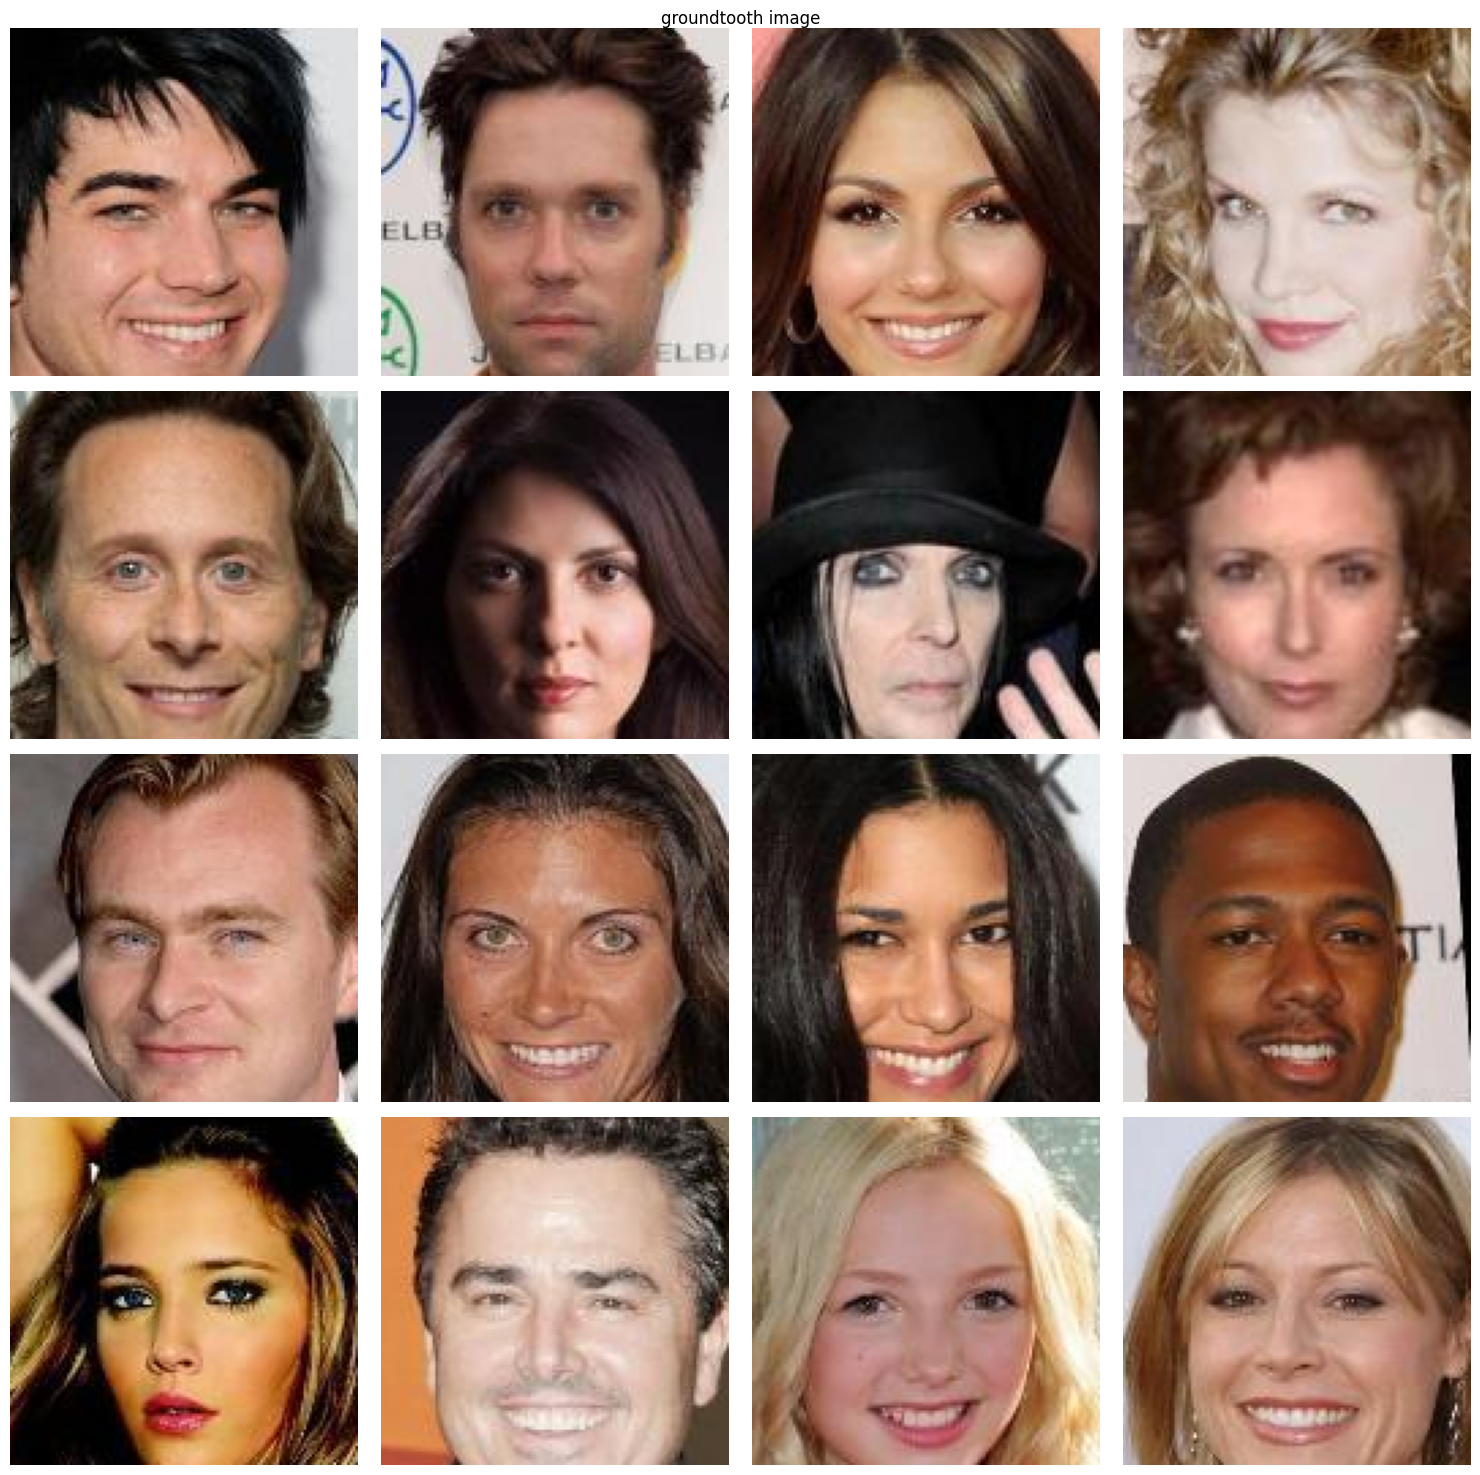

In [5]:
### START CODE HERE ###
data_dir = "/home/tdeephu/takdanai/data/img_align_celeba"

files = os.listdir(data_dir)
image_paths = [os.path.join(data_dir, file) for file in files]

dataset = CustomImageDataset(image_paths=image_paths,gauss_noise=True,center_crop=True,gauss_blur=True,resize=128,p=1.0
                            )
# ดึง example_index แรก
example_index = 16
example_dataset = [dataset[i] for i in range(example_index)]
noise_dataset = [sample[0] for sample in example_dataset]
gt_dataset = [sample[1] for sample in example_dataset]


imshow_grid(noise_dataset,"noise image")
imshow_grid(gt_dataset,"groundtooth image")

dataloader = DataLoader(dataset, batch_size=16)
### END CODE HERE ###

In [6]:
### START CODE HERE ###
batch,gt_img = next(iter(dataloader)) 
### END CODE HERE ###

## Create Autoencoder model
You can design your own Autoencoder model with a customizable number of downsampling and upsampling blocks by passing a list of channel numbers for each layer based on the provided code below. However, please maintain the concept of 'Autoencoder'.

In [7]:
### START CODE HERE ###
class DownSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(DownSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

class UpSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(UpSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.upsample(x)
        return x


class Autoencoder(nn.Module):
    def __init__(self, channels=[64, 128, 256, 512], input_channels=3, output_channels=3):
        super().__init__()
        # Encoder
        self.conv_in = nn.Conv2d(input_channels, channels[0], kernel_size=3, stride=1, padding=1)
        self.down1 = DownSamplingBlock(channels[0], channels[1], kernel_size=3, stride=1, padding=1)
        self.down2 = DownSamplingBlock(channels[1], channels[2], kernel_size=3, stride=1, padding=1)
        # ch_in = input_channels
        # for ch_out in channels:
        #     down1 = DownSamplingBlock(channels[0], ch_out, kernel_size=3, stride=1, padding=1)
        #     ch_in = ch_out
        if len(channels) == 4 :
            self.down3 = DownSamplingBlock(channels[2], channels[3], kernel_size=3, stride=1, padding=1)
            # self.down4 = DownSamplingBlock(channels[3], channels[4], kernel_size=3, stride=1, padding=1)
        else:
            self.down3 = None
            # self.down4 = None
        

        # Decoder
        if len(channels) == 4 :
            # self.up4 = UpSamplingBlock(channels[4], channels[3], kernel_size=3, stride=1, padding=1)
            self.up3 = UpSamplingBlock(channels[3], channels[2], kernel_size=3, stride=1, padding=1)
            
        else:
            # self.up4 = None
            self.up3 = None
            
        # self.up3 = UpSamplingBlock(channels[3], channels[2], kernel_size=3, stride=1, padding=1)
        self.up2 = UpSamplingBlock(channels[2], channels[1], kernel_size=3, stride=1, padding=1)
        self.up1 = UpSamplingBlock(channels[1], channels[0], kernel_size=3, stride=1, padding=1)
        self.conv = nn.Conv2d(channels[0], output_channels, kernel_size=3, stride=1, padding=1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Encoder
        x = self.conv_in(x)
        x = self.down1(x)
        x = self.down2(x)
        if self.down3 :
            x = self.down3(x)
        

        # Decoder
        if self.up3:
            x = self.up3(x)
        x = self.up2(x)
        x = self.up1(x)
        x = self.conv(x)
        x = self.sigmoid(x)
        
        return x

### END CODE HERE ###

## Train Autoencoder
Complete the `train()` function in the cell below. This function should evaluate the model at every epoch, log the ***training loss, test loss,test PSNR, test SSIM***. Additionally, it should save the model at the last epoch.
<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The log should resemble this, but not be identical

```
🤖Training on cuda
🚀Training Epoch [1/1]: 100%|██████████| 1313/1313 [01:45<00:00, 12.41batch/s, loss=0.0102] 
📄Testing: 100%|██████████| 563/563 [01:10<00:00,  7.95batch/s, loss=0.0106, psnr=16.7, ssim=0.348] 
Summary :
	Train	avg_loss: 0.017262999383663165
	Test	avg_loss: 0.010476540363861867 
                PSNR : 16.839487147468034 
                SSIM : 0.36090552368883694
...
```

</details>

Resource : [PyTorch Training loop](<https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#:~:text=%3D0.9)-,The%20Training%20Loop,-Below%2C%20we%20have>), [PSNR & SSIM](https://ieeexplore.ieee.org/document/5596999)

In [8]:
### START CODE HERE ###
def train(model,opt,loss_fn,train_loader,test_loader,epochs=10,checkpoint_path=None,device='cpu'):
    def compute_psnr(batch_img1, batch_img2):
        # img ที่รับมาเป็น batch img1: torch.Size([16, 3, 128, 128]) img2: torch.Size([16, 3, 128, 128])
        psnr_vals = []
        for img1, img2 in zip(batch_img1, batch_img2):
            img1_np = img1.cpu().numpy().transpose(1, 2, 0)
            img2_np = img2.cpu().numpy().transpose(1, 2, 0)
            img1_np = img1_np.astype(np.float32)
            img2_np = img2_np.astype(np.float32)
            psnr_val = psnr(img1_np, img2_np, data_range=1)
            psnr_vals.append(psnr_val)
        return np.mean(psnr_vals)

    def compute_ssim(batch_img1, batch_img2):
        ssim_vals = []
        for img1, img2 in zip(batch_img1, batch_img2):
            img1_np = img1.cpu().numpy().transpose(1, 2, 0)
            img2_np = img2.cpu().numpy().transpose(1, 2, 0)
            img1_np = img1_np.astype(np.float32)
            img2_np = img2_np.astype(np.float32)
            ssim_val = ssim(img1_np, img2_np, channel_axis=2, data_range=1)
            ssim_vals.append(ssim_val)
        return np.mean(ssim_vals)
    
    print("🤖 Training on", device)
    model = model.to(device)
    
    writer = SummaryWriter()
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        
        # train
        model.train()
        total_train_loss = 0.0
        train_bar = tqdm(train_loader, desc=f'🚀 Training Epoch [{epoch+1}/{epochs}]', unit='batch')
        for images, gt in train_bar:
            images, gt = images.to(device), gt.to(device)
            # print("Hello",end="")
            # zero gradient
            opt.zero_grad()
            
            # เรียก forward
            outputs = model(images)
            
            # calculate loss
            loss = loss_fn(outputs, gt)
            total_train_loss += loss.item()
            
            # ทำ backward และ optimize กลับ
            loss.backward()
            opt.step()
            
            train_bar.set_postfix(loss=loss.item())
        
        
        avg_train_loss = total_train_loss / len(train_loader)
        # print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {avg_train_loss:.4f}")
        

        # test model ที่ train
        model.eval()
        total_test_loss = 0.0
        total_psnr = 0.0
        total_ssim = 0.0
        with torch.no_grad():
            test_bar = tqdm(test_loader, desc='📄Testing', unit='batch')
            for images, gt in test_bar:
                images, gt = images.to(device), gt.to(device)

                # ส่งรูปเข้าไปใน model
                outputs = model(images)
                
                # คำนวณ loss
                loss = loss_fn(outputs, gt)
                total_test_loss += loss.item()
                
                psnr_val = compute_psnr(outputs, gt)
                ssim_val = compute_ssim(outputs, gt)
                
                total_psnr += psnr_val
                total_ssim += ssim_val
                
                test_bar.set_postfix(loss=f"{loss.item():.4f}", psnr=psnr_val, ssim=ssim_val)
        
        avg_test_loss = total_test_loss / len(test_loader)
        avg_psnr = total_psnr / len(test_loader)
        avg_ssim = total_ssim / len(test_loader)

        print(f"Summary :\n\tTrain\tavg_loss: {avg_train_loss:.4f}\n\tTest\tavg_loss: {avg_test_loss:.4f} \n\t\tPSNR : {avg_psnr} \n\t\tSSIM : {avg_ssim}")
        
        # log ใส่ tensorboard
        writer.add_scalar('Loss/Train', avg_train_loss, epoch)
        writer.add_scalar('Loss/Test', avg_test_loss, epoch)
        writer.add_scalar('Metrics/PSNR', avg_psnr, epoch)
        writer.add_scalar('Metrics/SSIM', avg_ssim, epoch)
        # เซฟ epoch ที่เทพสุดไว้
        if checkpoint_path and avg_test_loss < best_val_loss:
            best_val_loss = avg_test_loss
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Saved Best Model at Epoch {epoch+1} with Val Loss: {best_val_loss:.4f}'")
        # # เซฟ checkpoint
        # if checkpoint_path:
        #     torch.save(model.state_dict(), checkpoint_path)
    torch.save(model.state_dict(), "/home/tdeephu/lab6_test/checkpoint/last_epoch.pth")
    print(f"Saved Last Model at Epoch {epoch+1} with Val Loss: {best_val_loss:.4f}'")
    writer.close()
                
### END CODE HERE ###

Let's train your model with 2 epochs to verify that your train() function works properly. After that, we'll move on to the Hyperparameter Grid Search in the next part.

In [9]:
### START CODE HERE ###

data_dir = "/home/tdeephu/takdanai/data/img_align_celeba"

files = os.listdir(data_dir)
files = [os.path.join(data_dir, file) for file in files]
tiny_data = random.sample(files, 3000)

# แบ่ง dataset เป็น test กับ train 20% กับ 80%
# train_files, test_files = train_test_split(files, test_size=0.2,train_size=0.8, random_state=42)
train_files, test_files = train_test_split(tiny_data, test_size=0.2,train_size=0.8, random_state=42)
# print(tiny_data[:10])

train_dataset = CustomImageDataset(image_paths=train_files, center_crop=False,gauss_noise=True,gauss_blur=True, resize=128, p=1.0)
test_dataset = CustomImageDataset(image_paths=test_files, center_crop=False,gauss_noise=True,gauss_blur=True, resize=128, p=1.0)
trainloader = DataLoader(train_dataset, batch_size=16, shuffle=True,num_workers=16)
testloader = DataLoader(test_dataset, batch_size=16, shuffle=False,num_workers=16)

### END CODE HERE ###

In [ ]:
### START CODE HERE ###

model = Autoencoder()
opt = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
train(model=model,
    opt=opt,
    loss_fn=loss_fn,
    train_loader=trainloader,  
    test_loader=testloader,    
    epochs=2,                 
    checkpoint_path="/home/tdeephu/lab6_test/checkpoint/best_checkpoint.pth",  
    device='cuda' if torch.cuda.is_available() else 'cpu')
### END CODE HERE ###

🤖 Training on cuda


📄Testing: 100%|██████████| 38/38 [00:02<00:00, 13.26batch/s, loss=0.0172, psnr=17.8, ssim=0.484]


Summary :
	Train	avg_loss: 0.0230
	Test	avg_loss: 0.0178 
		PSNR : 17.759238527836132 
		SSIM : 0.4644132021226381
Saved Best Model at Epoch 1 with Val Loss: 0.0178'


🚀 Training Epoch [2/2]:  37%|███▋      | 55/150 [00:02<00:02, 43.63batch/s, loss=0.0211]

📄Testing: 100%|██████████| 38/38 [00:03<00:00, 12.65batch/s, loss=0.0144, psnr=18.7, ssim=0.521]


Summary :
	Train	avg_loss: 0.0178
	Test	avg_loss: 0.0150 
		PSNR : 18.558657344191484 
		SSIM : 0.5098074509909278
Saved Best Model at Epoch 2 with Val Loss: 0.0150'
Saved Last Model at Epoch 2 with Val Loss: 0.0150'


---

## **Hyperparameter Grid Search with Raytune**

*If you have access to APEX, I would recommend converting this part into a Python file and submitting the job to run on APEX using SBATCH. This process may take a considerable amount of time.*

You can import additional Ray Tune tools as you want, such as schedulers, search algorithms, etc. Further information on the usage of Ray Tune can be found [here](https://docs.ray.io/en/latest/tune/index.html).

In [10]:
import ray
from ray import tune,train
from ray.air import session
from ray.train import Checkpoint,RunConfig
import tempfile
from ray.tune.schedulers import ASHAScheduler

ray.shutdown()

Complete the `train_raytune()` function below, following the [quick start guide](https://docs.ray.io/en/latest/tune/index.html). This function will be passed to the `tune.Tuner`.

In [11]:
### START CODE HERE ###
def train_raytune(config):
    def compute_psnr(batch_img1, batch_img2):
        # img ที่รับมาเป็น batch img1: torch.Size([16, 3, 128, 128]) img2: torch.Size([16, 3, 128, 128])
        psnr_vals = []
        for img1, img2 in zip(batch_img1, batch_img2):
            img1_np = img1.cpu().numpy().transpose(1, 2, 0)
            img2_np = img2.cpu().numpy().transpose(1, 2, 0)
            img1_np = img1_np.astype(np.float32)
            img2_np = img2_np.astype(np.float32)
            psnr_val = psnr(img1_np, img2_np, data_range=1)
            psnr_vals.append(psnr_val)
        return np.mean(psnr_vals)

    def compute_ssim(batch_img1, batch_img2):
        ssim_vals = []
        for img1, img2 in zip(batch_img1, batch_img2):
            img1_np = img1.cpu().numpy().transpose(1, 2, 0)
            img2_np = img2.cpu().numpy().transpose(1, 2, 0)
            img1_np = img1_np.astype(np.float32)
            img2_np = img2_np.astype(np.float32)
            ssim_val = ssim(img1_np, img2_np, channel_axis=2, data_range=1)
            ssim_vals.append(ssim_val)
        return np.mean(ssim_vals)

    torch.manual_seed(4912)

    trainloader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True ,num_workers=11)
    testloader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False,num_workers=11)

    model = Autoencoder(channels=config['architecture'])
    loss_fn = nn.MSELoss()
    device= 'cuda' if torch.cuda.is_available() else 'cpu'


    if config['optimizer'] == 'Adam':
        opt = torch.optim.Adam(model.parameters(),lr=config['lr'])
    elif config['optimizer'] == 'SGD':
        opt = torch.optim.SGD(model.parameters(),lr=config['lr'])

    model = model.to(device)

    # # Load from checkpoint if available
    # start_epoch = 1
    # checkpoint = train.get_checkpoint()
    # if checkpoint:
    #     with checkpoint.as_directory() as checkpoint_dir:
    #         checkpoint_data = torch.load(os.path.join(checkpoint_dir, "checkpoint.pt"))
    #         start_epoch = checkpoint_data["epoch"] + 1
    #         model.load_state_dict(checkpoint_data["model_state"])
    #         opt.load_state_dict(checkpoint_data["optimizer_state"])



    for epoch in range(config['num_epochs']):
        model.train()
        avg_train_loss = 0
        total_train_loss = 0.0
        for images, gt in trainloader:
            images, gt = images.to(device), gt.to(device)
            # print("Hello",end="")
            # zero gradient
            opt.zero_grad()

            # เรียก forward
            outputs = model(images)

            # calculate loss
            loss = loss_fn(outputs, gt)
            total_train_loss += loss.item()

            # ทำ backward และ optimize กลับ
            loss.backward()
            opt.step()


        avg_train_loss = total_train_loss / len(trainloader)

        # test model ที่ train
        total_test_loss = 0.0
        total_psnr = 0.0
        total_ssim = 0.0
        model.eval()
        with torch.no_grad():
            for images, gt in testloader:
                images, gt = images.to(device), gt.to(device)

                # ส่งรูปเข้าไปใน model
                outputs = model(images)

                # คำนวณ loss
                loss = loss_fn(outputs, gt)
                total_test_loss += loss.item()

                psnr_val = compute_psnr(outputs, gt)
                ssim_val = compute_ssim(outputs, gt)

                total_psnr += psnr_val
                total_ssim += ssim_val





        avg_test_loss = total_test_loss / len(testloader)
        avg_psnr = total_psnr / len(testloader)
        avg_ssim = total_ssim / len(testloader)

        session.report({
            "train_loss": avg_train_loss,
            "val_loss": avg_test_loss,
            "val_psnr": avg_psnr,
            "val_ssim": avg_ssim,
        })
        
        # # Report metrics and save the checkpoint
        # metrics = {
        #     "train_loss": avg_train_loss,
        #     "val_loss": avg_test_loss,
        #     "val_psnr": avg_psnr,
        #     "val_ssim": avg_ssim,
        # }

        # with tempfile.TemporaryDirectory() as tempdir:
        #     torch.save({
        #         "epoch": epoch,
        #         "model_state": model.state_dict(),
        #         "optimizer_state": opt.state_dict(),
        #     }, os.path.join(tempdir, "checkpoint.pt"))

        #     # Report metrics and the current checkpoint
        #     train.report(metrics=metrics, checkpoint=Checkpoint.from_directory(tempdir))

### END CODE HERE ###

Initialize Ray, define the search space, and resources.

Resource : 
- [A Guide To Parallelism and Resources for Ray Tune](https://docs.ray.io/en/latest/tune/tutorials/tune-resources.html#:~:text=A%20Guide%20To%20Parallelism%20and%20Resources%20for%20Ray%20Tune) 
- [Working with Tune Search Spaces](https://docs.ray.io/en/latest/tune/tutorials/tune-search-spaces.html#tune-search-space-tutorial:~:text=Working%20with%20Tune%20Search%20Spaces)
- [How to configure logging in Tune?](https://docs.ray.io/en/latest/tune/tutorials/tune-output.html) 
- [Tune Trial Schedulers (`tune.schedulers`)](https://docs.ray.io/en/latest/tune/api/schedulers.html#tune-scheduler-pbt:~:text=Tune%20Trial...-,Tune%20Trial%20Schedulers%20(tune.schedulers),-%23)

**Search Space:**
- `architecture`:<br>
    Feature map dimensions for convolutional layers<br>
    - `[32, 64, 128]`: 3 downsampling layers with feature maps increasing from 32 to 128.
    - `[64, 128, 256]`: 3 downsampling layers with feature maps starting from 64 to 256.
    - `[64, 128, 256, 512]`: 4 downsampling layers with more depth, starting from 64 and ending at 512.
- `learning rates (lr)`:
    - [1e-3, 8e-4, 1e-4, 1e-2]: Test a wide range of learning rates to evaluate model performance, from 1e-3 (typical) to a more aggressive 1e-2 or conservative 1e-4.
- `batch size`:
    - [16, 32]: Explore smaller batch sizes to evaluate their impact on gradient estimation and memory usage.
- `number of epochs`:
    - `[10, 50, 100]`: Allow short and long training sessions, from quick evaluations (10 epochs) to more extensive training (100 epochs).
- `optimizers (opts)`:
    - `["Adam", "SGD"]`: Compare two popular optimization algorithms: Adam for adaptive learning rates and SGD for momentum-based updates.

In [ ]:
import ray
ray.shutdown()
ray.init(num_gpus=1,)
ray.available_resources()

2025-08-28 13:38:44,061	INFO worker.py:1777 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


{'node:172.16.101.112': 1.0,
 'accelerator_type:A100': 1.0,
 'node:__internal_head__': 1.0,
 'CPU': 256.0,
 'object_store_memory': 200000000000.0,
 'memory': 722936785920.0,
 'GPU': 1.0}

In [ ]:
### START CODE HERE ###
ray.shutdown()
ray.init(num_gpus=1,)


config = {
    'model_name':'Grid_Autoencoder',
    "architecture": tune.grid_search([[32, 64, 128],[64, 128, 256], [64, 128, 256, 512]]), 
    'optimizer':tune.grid_search(['Adam','SGD']),
    'lr':tune.grid_search([1e-2, 1e-3, 1e-4, 8e-4]),
    'batch_size': tune.grid_search([16, 32]),
    'num_epochs': tune.grid_search([10, 50, 100]),

}

tuner = tune.Tuner(
    tune.with_resources(train_raytune,resources={'gpu':0.33,'cpu':12}),
    tune_config = tune.TuneConfig(
        metric="val_psnr",
        mode="max",
        # scheduler = ASHAScheduler()
    ),
    param_space = config,
    run_config = RunConfig(
        storage_path="/home/tdeephu/lab6_test/ray_restore",
        name="grid_search_down",
))
result = tuner.fit()

### END CODE HERE ###

2025-08-28 13:39:06,795	WARNING tune_controller.py:2132 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (281 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2025-08-28 13:39:06,797	WARNING tune_controller.py:2132 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (281 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2025-08-28 21:06:12,310	WARNING experiment_state.py:233 -- Saving the experiment state (which 

Restore the result from path of ray resule directory

In [ ]:
### START CODE HERE ###
path = "/home/tdeephu/lab6_test/ray_restore/grid_search_down"
restored_tuner = tune.Tuner.restore(path, trainable='train_raytune')
### END CODE HERE ###

Get the report from Grid Search to CSV file.

In [ ]:
print("🎉[INFO] Training is done!")
print("Best config is:", result.get_best_result().config)
print("Best result is:", result.get_best_result())
df = result.get_dataframe()
df
df.to_csv("/home/tdeephu/lab6_test/result/grid_result.csv",index=False)

# ray.shutdown()

🎉[INFO] Training is done!
Best config is: {'model_name': 'Grid_Autoencoder', 'architecture': [64, 128, 256, 512], 'optimizer': 'Adam', 'lr': 0.001, 'batch_size': 16, 'num_epochs': 100}
Best result is: Result(
  metrics={'train_loss': 0.005000725385422508, 'val_loss': 0.005258475687648905, 'val_psnr': 23.26813879657049, 'val_ssim': 0.7281295312078375},
  path='/home/tdeephu/lab6_test/ray_restore/grid_search_down/train_raytune_b2039_00056_56_architecture=64_128_256_512,batch_size=16,lr=0.0010,num_epochs=100,optimizer=Adam_2025-08-28_13-39-07',
  filesystem='local',
  checkpoint=None
)


---

Train the Autoencoder models using the best hyperparameter set obtained from the grid search.

In [18]:
### START CODE HERE ###

def train_with_best_config(best_config,checkpoint_name):
    def compute_psnr(batch_img1, batch_img2):
        psnr_vals = []
        for img1, img2 in zip(batch_img1, batch_img2):
            img1_np = img1.cpu().numpy().transpose(1, 2, 0)
            img2_np = img2.cpu().numpy().transpose(1, 2, 0)
            img1_np = img1_np.astype(np.float32)
            img2_np = img2_np.astype(np.float32)
            psnr_val = psnr(img1_np, img2_np, data_range=1)
            psnr_vals.append(psnr_val)
        return np.mean(psnr_vals)

    def compute_ssim(batch_img1, batch_img2):
        ssim_vals = []
        for img1, img2 in zip(batch_img1, batch_img2):
            img1_np = img1.cpu().numpy().transpose(1, 2, 0)
            img2_np = img2.cpu().numpy().transpose(1, 2, 0)
            img1_np = img1_np.astype(np.float32)
            img2_np = img2_np.astype(np.float32)
            ssim_val = ssim(img1_np, img2_np, channel_axis=2, data_range=1)
            ssim_vals.append(ssim_val)
        return np.mean(ssim_vals)

    torch.manual_seed(4912)

    trainloader = DataLoader(train_dataset, batch_size=best_config['batch_size'], shuffle=True, num_workers=16)
    testloader = DataLoader(test_dataset, batch_size=best_config['batch_size'], shuffle=False, num_workers=16)

    model = Autoencoder(channels=best_config['architecture'])
    loss_fn = nn.MSELoss()
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    if best_config['optimizer'] == 'Adam':
        opt = torch.optim.Adam(model.parameters(), lr=best_config['lr'])
    elif best_config['optimizer'] == 'SGD':
        opt = torch.optim.SGD(model.parameters(), lr=best_config['lr'])

    model = model.to(device)

    for epoch in range(best_config['num_epochs']):
        model.train()
        total_train_loss = 0.0
        train_bar = tqdm(trainloader, desc=f'🚀 Training Epoch [{epoch+1}/{best_config["num_epochs"]}]', unit='batch')
        for images, gt in train_bar:
            images, gt = images.to(device), gt.to(device)
            opt.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, gt)
            loss.backward()
            opt.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(trainloader)

        model.eval()
        total_test_loss = 0.0
        total_psnr = 0.0
        total_ssim = 0.0
        with torch.no_grad():
            test_bar = tqdm(testloader, desc='📄Testing', unit='batch')
            for images, gt in test_bar:
                images, gt = images.to(device), gt.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, gt)
                total_test_loss += loss.item()
                psnr_val = compute_psnr(outputs, gt)
                ssim_val = compute_ssim(outputs, gt)
                total_psnr += psnr_val
                total_ssim += ssim_val

        avg_test_loss = total_test_loss / len(testloader)
        avg_psnr = total_psnr / len(testloader)
        avg_ssim = total_ssim / len(testloader)

        print(f"Epoch [{epoch + 1}/{best_config['num_epochs']}], "
              f"Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, "
              f"PSNR: {avg_psnr:.4f}, SSIM: {avg_ssim:.4f}")
    
    torch.save(model.state_dict(), f"/home/tdeephu/lab6_test/save/{checkpoint_name}.pth")
    print("🎉[INFO] Training with the best configuration is done!")

best_grid_name = "best_grid_checkpoint"
best_config = result.get_best_result().config
train_with_best_config(best_config,best_grid_name)
### END CODE HERE ###

📄Testing: 100%|██████████| 38/38 [00:03<00:00, 12.39batch/s]


Epoch [1/94], Train Loss: 0.0219, Test Loss: 0.0200, PSNR: 17.2888, SSIM: 0.4679


📄Testing: 100%|██████████| 38/38 [00:03<00:00, 12.40batch/s]


Epoch [2/94], Train Loss: 0.0169, Test Loss: 0.0242, PSNR: 16.3816, SSIM: 0.4734


📄Testing: 100%|██████████| 38/38 [00:03<00:00, 12.31batch/s]


...

Epoch [92/94], Train Loss: 0.0050, Test Loss: 0.0069, PSNR: 22.2239, SSIM: 0.7214


📄Testing: 100%|██████████| 38/38 [00:03<00:00, 12.39batch/s]


Epoch [93/94], Train Loss: 0.0050, Test Loss: 0.0056, PSNR: 22.9835, SSIM: 0.7265


📄Testing: 100%|██████████| 38/38 [00:03<00:00, 12.07batch/s]


Epoch [94/94], Train Loss: 0.0050, Test Loss: 0.0056, PSNR: 22.9709, SSIM: 0.7219
🎉[INFO] Training with the best configuration is done!


Use the `FeatureExtractor()` class and `visualize_feature_map()` function to visualize the feature map of ***ALL*** layers. Then, save it as an image.


In [12]:
import math
class FeatureMapVisualizer:
    def __init__(self, model, layers, save_dir):
        """
        Parameters:
        - model: The PyTorch model
        - layers: A string or list of strings specifying the layer names to visualize
        - save_dir: Directory to save the output feature map images
        """
        self.model = model
        self.layers = layers if isinstance(layers, list) else [layers]
        self.activations = {}
        self.save_dir = save_dir

        os.makedirs(self.save_dir, exist_ok=True)

        self._register_hooks()

    def _register_hooks(self):
        for name, layer in self.model.named_modules():
            if name in self.layers:
                layer.register_forward_hook(self._hook_fn(name))

    def _hook_fn(self, layer_name):
        def hook(module, input, output):
            print(f'Hooking layer: {layer_name}')
            self.activations[layer_name] = output.detach()
        return hook

    def visualize(self, input_paths):
        """
        Pass an input tensor through the model and visualize the activations.
        
        Parameters:
        - input_paths: List of image paths to pass through the model
        """
        
        # for img_path in input_paths:
        with torch.no_grad():
            self.model(input_paths)

        for layer_name, activation in self.activations.items():
            print(f'Visualizing and saving layer: {layer_name}')
            self._save_feature_maps(activation, layer_name)

    def _save_feature_maps(self, activation, layer_name):
        ### START CODE HERE ###
        num_channels = activation.shape[1]  # Number of feature maps
        grid_size = math.ceil(math.sqrt(num_channels))  # หา กว้างยาวโดย sqrt ex. 4*4

        fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
        fig.suptitle(f"Feature maps of {layer_name}")
        
        for i in range(grid_size * grid_size):
            ax = axes[i // grid_size, i % grid_size]
            if i < num_channels:
                # feature_map = activation[0, i, :, :].cpu().numpy()  # ดึงมา 1 feature map
                feature_map = activation[0, i, :, :].cpu()  # ดึงมา 1 feature map
                # feature_map = (feature_map - feature_map.min()) / (feature_map.max() - feature_map.min())  # norm to [0, 1]
                ax.imshow(feature_map,cmap="grey")
            ax.axis('off')

        # Save the figure
        plt.tight_layout()
        save_path = os.path.join(self.save_dir, f"{layer_name}.png")
        plt.savefig(save_path)
        plt.close(fig)
        print(f"Saved feature maps for layer {layer_name} to {save_path}")
### END CODE HERE ###

In [14]:
### START CODE HERE ###
best_grid_name = "best_grid_checkpoint"

model = Autoencoder()
model_weights_path = f'/home/tdeephu/lab6_test/save/{best_grid_name}.pth'
model.load_state_dict(torch.load(model_weights_path))
model.to("cuda:0")


layers_to_visualize = [name for name, _ in model.named_modules()]
print(layers_to_visualize)


save_dir = "/home/tdeephu/lab6_test/save/bestGridSearch"
visualizer = FeatureMapVisualizer(model, layers_to_visualize, save_dir)
visualizer.visualize(batch.to('cuda'))


### END CODE HERE ###

/tmp/ipykernel_359961/3600409404.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_weights_path))


['', 'conv_in', 'down1', 'down1.conv', 'down1.bn', 'down1.relu', 'down1.pool', 'down2', 'down2.conv', 'down2.bn', 'down2.relu', 'down2.pool', 'down3', 'down3.conv', 'down3.bn', 'down3.relu', 'down3.pool', 'up3', 'up3.conv', 'up3.bn', 'up3.relu', 'up3.upsample', 'up2', 'up2.conv', 'up2.bn', 'up2.relu', 'up2.upsample', 'up1', 'up1.conv', 'up1.bn', 'up1.relu', 'up1.upsample', 'conv', 'sigmoid']
Hooking layer: conv_in
Hooking layer: down1.conv
Hooking layer: down1.bn
Hooking layer: down1.relu
Hooking layer: down1.pool
Hooking layer: down1
Hooking layer: down2.conv
Hooking layer: down2.bn
Hooking layer: down2.relu
Hooking layer: down2.pool
Hooking layer: down2
Hooking layer: down3.conv
Hooking layer: down3.bn
Hooking layer: down3.relu
Hooking layer: down3.pool
Hooking layer: down3
Hooking layer: up3.conv
Hooking layer: up3.bn
Hooking layer: up3.relu
Hooking layer: up3.upsample
Hooking layer: up3
Hooking layer: up2.conv
Hooking layer: up2.bn
Hooking layer: up2.relu
Hooking layer: up2.upsampl

---
## **Hyperparameter Random Search with Raytune**

**Search Space:**

- **`architecture`:**  
    Define the feature map dimensions for convolutional layers:  
    - `[32, 64, 128]`: 3 downsampling layers with feature maps increasing from 32 to 128.
    - `[64, 128, 256]`: 3 downsampling layers with feature maps starting from 64 to 256.
    - `[64, 128, 256, 512]`: 4 downsampling layers with additional depth, starting from 64 and ending at 512.
  
- **`learning rates (lr)`**:  
    A continuous range of learning rates sampled uniformly between `1e-4` and `1e-2`. This allows exploration of different learning rates from conservative (`1e-4`) to more aggressive (`1e-2`) values.

- **`batch size`**:  
    Randomly sample an integer batch size between 16 and 32 (inclusive). This allows testing of smaller batch sizes, which can affect gradient estimation and memory usage.

- **`number of epochs`**:  
    Randomly sample an integer number of epochs between 10 and 100. This allows the model to train for short (e.g., 10 epochs) or extended periods (up to 100 epochs), giving insight into model performance over different training durations.

- **`optimizers (opts)`**:  
    Randomly select between two optimizers:  
    - `"Adam"`: An adaptive learning rate optimizer that generally performs well across various tasks.  
    - `"SGD"`: Stochastic Gradient Descent with momentum, commonly used for large-scale tasks, requiring careful tuning of the learning rate.

***NOTE*** Random search with 80 samples.

In [15]:
# ### START CODE HERE ###
ray.shutdown()
!nvidia-smi
torch.cuda.empty_cache()
ray.init(num_gpus=1,)
config = {
    'architecture': tune.choice([[32, 64, 128],[64, 128, 256], [64, 128, 256, 512]]),
    'batch_size': tune.randint(16,33),
    'lr': tune.loguniform(1e-4, 1e-2),
    'optimizer': tune.choice(['SGD', 'Adam']),
    'num_epochs': tune.randint(10, 101)
    
}


tuner = tune.Tuner(
    tune.with_resources(train_raytune,resources={'gpu':0.25, 'cpu': 12}),
    tune_config = tune.TuneConfig(
        metric="val_psnr",
        mode="max",
        
        # scheduler = ASHAScheduler(),
        num_samples=80
    ),
    param_space = config,
    run_config = RunConfig(
        storage_path="/home/tdeephu/lab6_test/ray_restore",
        name="rand_search",)
)
result = tuner.fit()
### END CODE HERE ###

2025-08-29 10:36:42,752	WARNING tune_controller.py:2132 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (281 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2025-08-29 10:36:42,754	WARNING tune_controller.py:2132 -- The maximum number of pending trials has been automatically set to the number of available cluster CPUs, which is high (281 CPUs/pending trials). If you're running an experiment with a large number of trials, this could lead to scheduling overhead. In this case, consider setting the `TUNE_MAX_PENDING_TRIALS_PG` environment variable to the desired maximum number of concurrent pending trials.
2025-08-29 13:55:52,539	WARNING util.py:201 -- The `on_step_begin` operation took 0.613 s, whi

In [16]:
print("🎉[INFO] Training is done!")
print("Best config is:", result.get_best_result().config)
print("Best result is:", result.get_best_result())
df = result.get_dataframe()
df
df.to_csv("/home/tdeephu/lab6_test/result/random_result.csv",index=False)

# ray.shutdown()

🎉[INFO] Training is done!
Best config is: {'architecture': [64, 128, 256, 512], 'batch_size': 16, 'lr': 0.0008457403112454628, 'optimizer': 'Adam', 'num_epochs': 94}
Best result is: Result(
  metrics={'train_loss': 0.005017380138548712, 'val_loss': 0.0056234311287928565, 'val_psnr': 22.92328517938581, 'val_ssim': 0.7220484551630522},
  path='/home/tdeephu/lab6_test/ray_restore/rand_search/train_raytune_61428_00023_23_architecture=64_128_256_512,batch_size=16,lr=0.0008,num_epochs=94,optimizer=Adam_2025-08-29_10-36-43',
  filesystem='local',
  checkpoint=None
)


---

Train the Autoencoder models using the best hyperparameter set obtained from the random search.

In [19]:
### START CODE HERE ###
best_rand_name = "best_rand_checkpoint"
best_config = result.get_best_result().config
train_with_best_config(best_config,best_rand_name)

### END CODE HERE ###

🚀 Training Epoch [1/94]:   0%|          | 0/150 [00:00<?, ?batch/s]

📄Testing: 100%|██████████| 38/38 [00:03<00:00, 12.24batch/s]


Epoch [1/94], Train Loss: 0.0216, Test Loss: 0.0196, PSNR: 17.4397, SSIM: 0.4741


📄Testing: 100%|██████████| 38/38 [00:03<00:00, 12.37batch/s]


Epoch [2/94], Train Loss: 0.0168, Test Loss: 0.0225, PSNR: 16.7658, SSIM: 0.4786


...

Epoch [92/94], Train Loss: 0.0050, Test Loss: 0.0065, PSNR: 22.4449, SSIM: 0.7230


📄Testing: 100%|██████████| 38/38 [00:02<00:00, 12.81batch/s]


Epoch [93/94], Train Loss: 0.0050, Test Loss: 0.0055, PSNR: 23.0338, SSIM: 0.7281


📄Testing: 100%|██████████| 38/38 [00:03<00:00, 12.20batch/s]

Epoch [94/94], Train Loss: 0.0050, Test Loss: 0.0055, PSNR: 23.0298, SSIM: 0.7237
🎉[INFO] Training with the best configuration is done!


Use the `FeatureExtractor()` class and `visualize_feature_map()` function to visualize the feature map of ***ALL*** layers of the Convolution Feature Extractor part. Then, save it as an image.

In [20]:
### START CODE HERE ###


model = Autoencoder()
model_weights_path = "/home/tdeephu/lab6_test/save/best_rand_checkpoint.pth"
model.load_state_dict(torch.load(model_weights_path))
model.to("cuda:0")


layers_to_visualize = [name for name, _ in model.named_modules()]
print(layers_to_visualize)


save_dir = "/home/tdeephu/lab6_test/save/bestRandSearch"
visualizer = FeatureMapVisualizer(model, layers_to_visualize, save_dir)
visualizer.visualize(batch.to('cuda'))



### END CODE HERE ###

/tmp/ipykernel_359961/4107100380.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_weights_path))


['', 'conv_in', 'down1', 'down1.conv', 'down1.bn', 'down1.relu', 'down1.pool', 'down2', 'down2.conv', 'down2.bn', 'down2.relu', 'down2.pool', 'down3', 'down3.conv', 'down3.bn', 'down3.relu', 'down3.pool', 'up3', 'up3.conv', 'up3.bn', 'up3.relu', 'up3.upsample', 'up2', 'up2.conv', 'up2.bn', 'up2.relu', 'up2.upsample', 'up1', 'up1.conv', 'up1.bn', 'up1.relu', 'up1.upsample', 'conv', 'sigmoid']
Hooking layer: conv_in
Hooking layer: down1.conv
Hooking layer: down1.bn
Hooking layer: down1.relu
Hooking layer: down1.pool
Hooking layer: down1
Hooking layer: down2.conv
Hooking layer: down2.bn
Hooking layer: down2.relu
Hooking layer: down2.pool
Hooking layer: down2
Hooking layer: down3.conv
Hooking layer: down3.bn
Hooking layer: down3.relu
Hooking layer: down3.pool
Hooking layer: down3
Hooking layer: up3.conv
Hooking layer: up3.bn
Hooking layer: up3.relu
Hooking layer: up3.upsample
Hooking layer: up3
Hooking layer: up2.conv
Hooking layer: up2.bn
Hooking layer: up2.relu
Hooking layer: up2.upsampl

---

# Questions

1. How many combinations of hyperparameter values (trials) were evaluated during the hyperparameter tuning process?
2. What are the top 3 best parameters and their corresponding tuning results for the model?
3. Analyze and compare the similarities and differences between the top 3 parameters in terms of model architecture, loss, performance, etc.


